<a href="https://colab.research.google.com/github/Giankarl0/Data-Science/blob/integration/Demografia_Mundial.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Proyección demografica de población a nivel mundial**

https://datos.bancomundial.org/indicador/SP.POP.TOTL

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving POBLACION_TOTAL_BANCO_MUNDIAL.csv to POBLACION_TOTAL_BANCO_MUNDIAL.csv


In [ ]:
import pandas as pd

# Nombre del archivo subido
file_path = 'POBLACION_TOTAL_BANCO_MUNDIAL.csv'

# Cargar el archivo CSV
data = pd.read_csv(file_path, skiprows=4)
print(data.head())

  Country Name Country Code    Indicator Name Indicator Code         1960  \
0        Aruba          ABW  Población, total    SP.POP.TOTL      54922.0   
1          NaN          AFE  Población, total    SP.POP.TOTL  130072080.0   
2   Afganistán          AFG  Población, total    SP.POP.TOTL    9035043.0   
3          NaN          AFW  Población, total    SP.POP.TOTL   97630925.0   
4       Angola          AGO  Población, total    SP.POP.TOTL    5231654.0   

          1961         1962         1963         1964         1965  ...  \
0      55578.0      56320.0      57002.0      57619.0      58190.0  ...   
1  133534923.0  137171659.0  140945536.0  144904094.0  149033472.0  ...   
2    9214083.0    9404406.0    9604487.0    9814318.0   10036008.0  ...   
3   99706674.0  101854756.0  104089175.0  106388440.0  108772632.0  ...   
4    5301583.0    5354310.0    5408320.0    5464187.0    5521981.0  ...   

          2015         2016         2017         2018         2019  \
0     107906.0  

In [ ]:
# Validar valores faltantes o anómalos
print('Se Validan valores faltantes o anómalos\n')
data.info()

# Se validan los datos estadisticos
print('\nSe validan los datos estadisticos\n')
print(data.describe())

Se Validan valores faltantes o anómalos

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 266 entries, 0 to 265
Data columns (total 69 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Country Name    264 non-null    object 
 1   Country Code    266 non-null    object 
 2   Indicator Name  266 non-null    object 
 3   Indicator Code  266 non-null    object 
 4   1960            264 non-null    float64
 5   1961            264 non-null    float64
 6   1962            264 non-null    float64
 7   1963            264 non-null    float64
 8   1964            264 non-null    float64
 9   1965            264 non-null    float64
 10  1966            264 non-null    float64
 11  1967            264 non-null    float64
 12  1968            264 non-null    float64
 13  1969            264 non-null    float64
 14  1970            264 non-null    float64
 15  1971            264 non-null    float64
 16  1972            264 non-null    float64

**Limpiamos los datos**

In [ ]:
# Eliminar columnas completamente vacías
data_cleaned = data.dropna(axis=1, how='all')


Eliminar columnas innecesarias.

Primero, eliminaremos las columnas que no son relevantes, como Country Code, Indicator Name, Indicator Code y cualquier otra que no sea de interés para el análisis.

In [ ]:
# Filtrar las columnas necesarias (Country Name + Años de interés)
columns_to_keep = ['Country Name'] + [str(year) for year in range(1960, 2024)]
data_cleaned = data[columns_to_keep].copy()


Eliminar filas con valores faltantes en Country Name

Asegúrate de que todas las filas tengan un nombre de país válido.

In [ ]:
# Eliminar filas donde 'Country Name' sea NaN
data_cleaned = data_cleaned.dropna(subset=['Country Name'])


Rellenar valores faltantes en columnas de años

Para las columnas que representan años, puedes optar por:

Rellenar los valores faltantes con el promedio de cada columna.
Usar el valor anterior o posterior en el tiempo (relevante para datos temporales).

In [ ]:
# Rellenar valores faltantes con el promedio de la columna (años)
for year in range(1960, 2024):
    data_cleaned[str(year)].fillna(data_cleaned[str(year)].mean(), inplace=True)


<ipython-input-10-5fe220d5c82e>:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data_cleaned[str(year)].fillna(data_cleaned[str(year)].mean(), inplace=True)


Convertir columnas de años a tipo numérico

In [ ]:
# Convertir columnas de años a tipo float
for year in range(1960, 2024):
    data_cleaned[str(year)] = pd.to_numeric(data_cleaned[str(year)], errors='coerce')


In [ ]:
# Eliminar filas donde más del 50% de los años tengan valores NaN
data_cleaned = data_cleaned.dropna(thresh=len(columns_to_keep) * 0.5)



In [ ]:
# Verificar el resumen del DataFrame
print(data_cleaned.info())

# Revisar estadísticas descriptivas
print(data_cleaned.describe())


<class 'pandas.core.frame.DataFrame'>
Index: 264 entries, 0 to 265
Data columns (total 65 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Country Name  264 non-null    object 
 1   1960          264 non-null    float64
 2   1961          264 non-null    float64
 3   1962          264 non-null    float64
 4   1963          264 non-null    float64
 5   1964          264 non-null    float64
 6   1965          264 non-null    float64
 7   1966          264 non-null    float64
 8   1967          264 non-null    float64
 9   1968          264 non-null    float64
 10  1969          264 non-null    float64
 11  1970          264 non-null    float64
 12  1971          264 non-null    float64
 13  1972          264 non-null    float64
 14  1973          264 non-null    float64
 15  1974          264 non-null    float64
 16  1975          264 non-null    float64
 17  1976          264 non-null    float64
 18  1977          264 non-null    float

In [ ]:
import matplotlib.pyplot as plt

# Lista de países a analizar
countries = ["Afganistán","Albania","Alemania","Andorra","Angola","Antigua y Barbuda","Arabia Saudita","Argelia","Argentina","Armenia","Australia","Austria","Azerbaiyán","Bahamas","Bangladés","Barbados","Baréin","Bélgica","Belice","Benín","Bielorrusia","Birmania","Bolivia","Bosnia y Herzegovina","Botsuana","Brasil","Brunéi","Bulgaria","Burkina Faso","Burundi","Bután","Cabo Verde","Camboya","Camerún","Canadá","Catar","Chad","Chile","China","Chipre","Ciudad del Vaticano","Colombia","Comoras","Corea del Norte","Corea del Sur","Costa de Marfil","Costa Rica","Croacia","Cuba","Dinamarca","Dominica","Ecuador","Egipto","El Salvador","Emiratos Árabes Unidos","Eritrea","Eslovaquia","Eslovenia","España","Estados Unidos","Estonia","Etiopía","Filipinas","Finlandia","Fiyi","Francia","Gabón","Gambia","Georgia","Ghana","Granada","Grecia","Guatemala","Guyana","Guinea","Guinea ecuatorial","Guinea-Bisáu","Haití","Honduras","Hungría","India","Indonesia","Irak","Irán","Irlanda","Islandia","Islas Marshall","Islas Salomón","Israel","Italia","Jamaica","Japón","Jordania","Kazajistán","Kenia","Kirguistán","Kiribati","Kuwait","Laos","Lesoto","Letonia","Líbano","Liberia","Libia","Liechtenstein","Lituania","Luxemburgo","Madagascar","Malasia","Malaui","Maldivas","Malí","Malta","Marruecos","Mauricio","Mauritania","México","Micronesia","Moldavia","Mónaco","Mongolia","Montenegro","Mozambique","Namibia","Nauru","Nepal","Nicaragua","Níger","Nigeria","Noruega","Nueva Zelanda","Omán","Países Bajos","Pakistán","Palaos","Palestina","Panamá","Papúa Nueva Guinea","Paraguay","Perú","Polonia","Portugal","Reino Unido","República Centroafricana","República Checa","República de Macedonia","República del Congo","República Democrática del Congo","República Dominicana","República Sudafricana","Ruanda","Rumanía","Rusia","Samoa","San Cristóbal y Nieves","San Marino","San Vicente y las Granadinas","Santa Lucía","Santo Tomé y Príncipe","Senegal","Serbia","Seychelles","Sierra Leona","Singapur","Siria","Somalia","Sri Lanka","Suazilandia","Sudán","Sudán del Sur","Suecia","Suiza","Surinam","Tailandia","Tanzania","Tayikistán","Timor Oriental","Togo","Tonga","Trinidad y Tobago","Túnez","Turkmenistán","Turquía","Tuvalu","Ucrania","Uganda","Uruguay","Uzbekistán","Vanuatu","Venezuela","Vietnam","Yemen","Yibuti","Zambia","Zimbabue"]

# Lista para almacenar los países encontrados
paises_encontrados = []

# Revisar si cada país en la lista está presente en los datos limpios
for country in countries:
    country_data = data_cleaned[data_cleaned['Country Name'] == country]

    if not country_data.empty:  # Si se encuentra el país
        paises_encontrados.append(country)

# Imprimir la lista de países encontrados
print("Países encontrados:")
print(paises_encontrados)

# Calcular el total de países encontrados
total_encontrados = len(paises_encontrados)
print(f"\nTotal de países encontrados: {total_encontrados}")



Países encontrados:
['Afganistán', 'Albania', 'Alemania', 'Andorra', 'Angola', 'Antigua y Barbuda', 'Arabia Saudita', 'Argelia', 'Argentina', 'Armenia', 'Australia', 'Austria', 'Azerbaiyán', 'Bahamas', 'Barbados', 'Bélgica', 'Belice', 'Bolivia', 'Bosnia y Herzegovina', 'Brasil', 'Bulgaria', 'Burkina Faso', 'Burundi', 'Cabo Verde', 'Camboya', 'Camerún', 'Canadá', 'Chad', 'Chile', 'China', 'Chipre', 'Colombia', 'Comoras', 'Costa Rica', 'Croacia', 'Cuba', 'Dinamarca', 'Dominica', 'Ecuador', 'El Salvador', 'Emiratos Árabes Unidos', 'Eritrea', 'Eslovenia', 'España', 'Estados Unidos', 'Estonia', 'Etiopía', 'Filipinas', 'Finlandia', 'Francia', 'Gabón', 'Gambia', 'Georgia', 'Ghana', 'Granada', 'Grecia', 'Guatemala', 'Guyana', 'Guinea', 'Haití', 'Honduras', 'Hungría', 'India', 'Indonesia', 'Irlanda', 'Islandia', 'Islas Marshall', 'Islas Salomón', 'Israel', 'Italia', 'Jamaica', 'Japón', 'Jordania', 'Kirguistán', 'Kiribati', 'Kuwait', 'Letonia', 'Líbano', 'Liberia', 'Libia', 'Liechtenstein', 'Lit

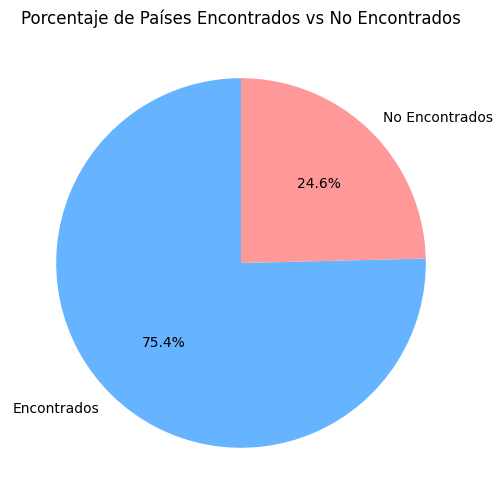

Países no encontrados:
['Yemen', 'Nueva Zelanda', 'Guinea ecuatorial', 'Fiyi', 'Surinam', 'Siria', 'República Democrática del Congo', 'Birmania', 'Botsuana', 'Rumanía', 'Vietnam', 'Irak', 'Lesoto', 'Ruanda', 'Corea del Norte', 'Bielorrusia', 'Corea del Sur', 'Timor Oriental', 'Rusia', 'Guinea-Bisáu', 'Costa de Marfil', 'Moldavia', 'Suazilandia', 'Laos', 'Catar', 'Yibuti', 'Zimbabue', 'Benín', 'Baréin', 'Brunéi', 'Kazajistán', 'Ciudad del Vaticano', 'Papúa Nueva Guinea', 'Malaui', 'República del Congo', 'Irán', 'Bután', 'Palestina', 'Palaos', 'República Sudafricana', 'Egipto', 'Bangladés', 'Micronesia', 'San Cristóbal y Nieves', 'Eslovaquia', 'República de Macedonia', 'Kenia', 'Tanzania']

Total de países no encontrados: 48


In [ ]:
# Visualizar el total de países encontrados
import matplotlib.pyplot as plt

totales = [total_encontrados, len(countries) - total_encontrados]
labels = ['Encontrados', 'No Encontrados']

plt.figure(figsize=(8, 6))
plt.pie(totales, labels=labels, autopct='%1.1f%%', startangle=90, colors=['#66b3ff', '#ff9999'])
plt.title('Porcentaje de Países Encontrados vs No Encontrados')
plt.show()


# Lista para almacenar los países encontrados
paises_encontrados = []

# Revisar si cada país en la lista está presente en los datos limpios
for country in countries:
    country_data = data_cleaned[data_cleaned['Country Name'] == country]

    if not country_data.empty:  # Si se encuentra el país
        paises_encontrados.append(country)

# Generar la lista de países no encontrados
paises_no_encontrados = list(set(countries) - set(paises_encontrados))

# Imprimir la lista de países no encontrados
print("Países no encontrados:")
print(paises_no_encontrados)

# Calcular el total de países no encontrados
total_no_encontrados = len(paises_no_encontrados)
print(f"\nTotal de países no encontrados: {total_no_encontrados}")

Top 5 países con mayor crecimiento poblacional (1960-2023):
    Country Name  Population_Change
109        India       1.002079e+09
40         China       7.436400e+08
184     Pakistán       2.017952e+08
106    Indonesia       1.928940e+08
174      Nigeria       1.828292e+08

Top 5 países con menor crecimiento poblacional (1960-2023):
    Country Name  Population_Change
248      Ucrania         -5091257.0
21      Bulgaria         -1420778.0
101      Hungría          -391781.0
99       Croacia          -280495.0
145      Letonia          -243534.0


<ipython-input-16-cfb364371c57>:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Population_Change', y='Country Name', data=top_5_mayor_crecimiento, palette='viridis', legend=False)


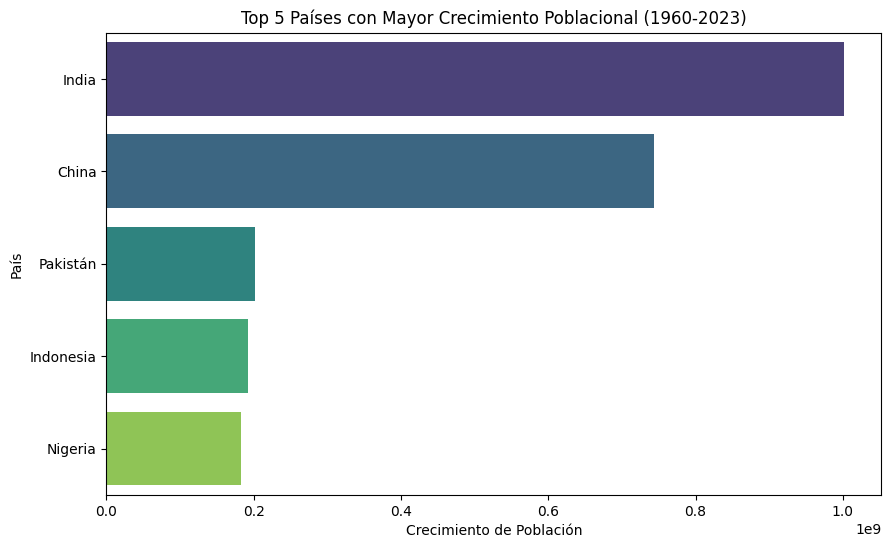

<ipython-input-16-cfb364371c57>:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Population_Change', y='Country Name', data=top_5_menor_crecimiento, palette='magma', legend=False)


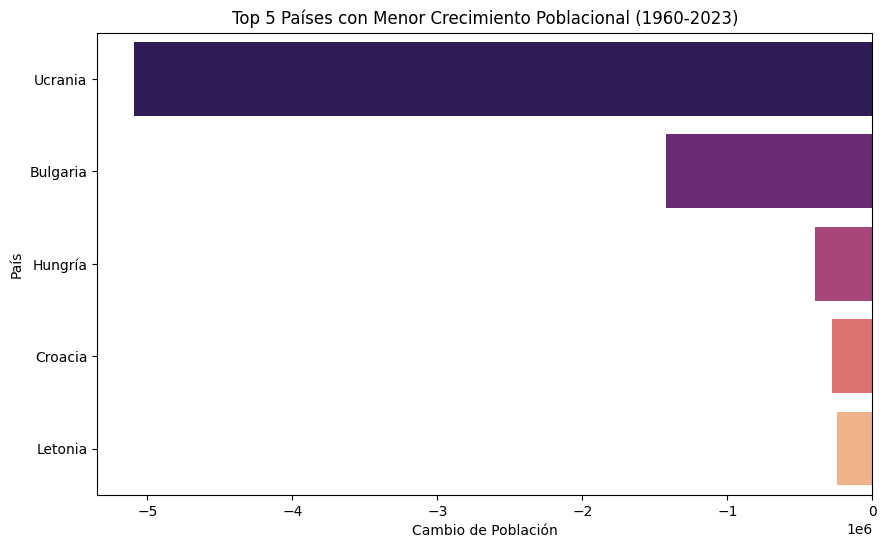

In [ ]:
# Filtrar solo los países encontrados en los datos limpios
data_paises_encontrados = data_cleaned[data_cleaned['Country Name'].isin(paises_encontrados)]

# Calcular el crecimiento absoluto (diferencia entre 2023 y 1960)
data_paises_encontrados = data_paises_encontrados.copy()
data_paises_encontrados['Population_Change'] = data_paises_encontrados['2023'] - data_paises_encontrados['1960']


# Obtener los 5 países con mayor crecimiento poblacional
top_5_mayor_crecimiento = data_paises_encontrados.nlargest(5, 'Population_Change')[['Country Name', 'Population_Change']]

# Obtener los 5 países con menor crecimiento (o mayor déficit poblacional)
top_5_menor_crecimiento = data_paises_encontrados.nsmallest(5, 'Population_Change')[['Country Name', 'Population_Change']]

# Imprimir los resultados
print("Top 5 países con mayor crecimiento poblacional (1960-2023):")
print(top_5_mayor_crecimiento)

print("\nTop 5 países con menor crecimiento poblacional (1960-2023):")
print(top_5_menor_crecimiento)

import matplotlib.pyplot as plt
import seaborn as sns

# Gráfico de los países con mayor crecimiento
plt.figure(figsize=(10, 6))
sns.barplot(x='Population_Change', y='Country Name', data=top_5_mayor_crecimiento, palette='viridis', legend=False)
plt.title('Top 5 Países con Mayor Crecimiento Poblacional (1960-2023)')
plt.xlabel('Crecimiento de Población')
plt.ylabel('País')
plt.show()


# Gráfico de los países con menor crecimiento
plt.figure(figsize=(10, 6))
sns.barplot(x='Population_Change', y='Country Name', data=top_5_menor_crecimiento, palette='magma', legend=False)
plt.title('Top 5 Países con Menor Crecimiento Poblacional (1960-2023)')
plt.xlabel('Cambio de Población')
plt.ylabel('País')
plt.show()


Crecimiento Relativo por Periodos

Descripción:
Analiza cómo ha variado el crecimiento poblacional en periodos específicos (por ejemplo, década por década).

Implementación:
Calcula la tasa de crecimiento relativa para cada década.
Compara periodos con alto y bajo crecimiento.

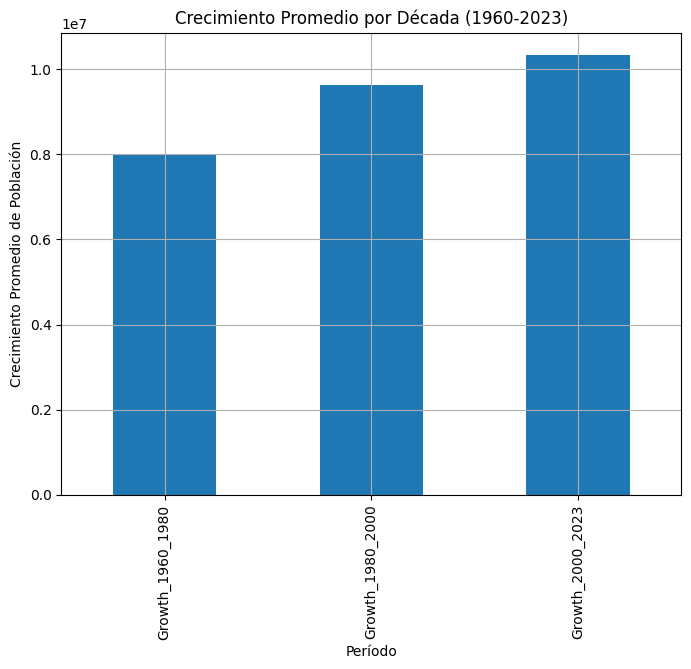

In [ ]:
# Calcular el crecimiento por décadas
data_paises_encontrados['Growth_1960_1980'] = data_paises_encontrados['1980'] - data_paises_encontrados['1960']
data_paises_encontrados['Growth_1980_2000'] = data_paises_encontrados['2000'] - data_paises_encontrados['1980']
data_paises_encontrados['Growth_2000_2023'] = data_paises_encontrados['2023'] - data_paises_encontrados['2000']

# Promediar el crecimiento por décadas
growth_by_decade = data_paises_encontrados[['Growth_1960_1980', 'Growth_1980_2000', 'Growth_2000_2023']].mean()

# Graficar crecimiento promedio por década
growth_by_decade.plot(kind='bar', figsize=(8, 6))
plt.title('Crecimiento Promedio por Década (1960-2023)')
plt.xlabel('Período')
plt.ylabel('Crecimiento Promedio de Población')
plt.grid()
plt.show()


Proyecciones de Población Futura

Descripción:
Usa modelos de predicción (como ARIMA, suavizamiento exponencial, o regresión lineal) para proyectar la población más allá de 2023.

El modelo usado es ARIMA, que pertenece al grupo de modelos estadísticos para series temporales. Es paramétrico, supervisado y asume estacionariedad. Aunque es una excelente opción para predecir datos históricos como la población, en algunos casos podría ser complementado o comparado con otros modelos, dependiendo de las características de los datos.

Impacto Relativo en la Población Global

Descripción:
Determina qué países han contribuido más (o menos) al crecimiento poblacional global desde 1960.

Implementación:
Calcula la proporción del cambio en la población de cada país respecto al cambio global.

Esto nos muestra cuáles han sido los motores principales del crecimiento poblacional global entre 1960 y 2023.

In [ ]:
# Calcular el cambio global en la población
global_change = data_paises_encontrados['Population_Change'].sum()

# Calcular la contribución relativa de cada país
data_paises_encontrados['Contribution_Global'] = (data_paises_encontrados['Population_Change'] / global_change) * 100

# Países con mayor contribución relativa
top_contributors = data_paises_encontrados.nlargest(10, 'Contribution_Global')[['Country Name', 'Contribution_Global']]
print(top_contributors)


       Country Name  Contribution_Global
109           India            24.391491
40            China            18.100852
184        Pakistán             4.911872
106       Indonesia             4.695210
174         Nigeria             4.450223
251  Estados Unidos             3.754432
29           Brasil             3.377360
72          Etiopía             2.612141
154          México             2.264070
187       Filipinas             2.117640


India tiene un Contribution_Global de 24.39%, lo que significa que aproximadamente 1 de cada 4 personas añadidas a la población mundial desde 1960 provienen de India.

Interpretación por Países
India (24.39%):

Es el país que más ha contribuido al crecimiento poblacional global desde 1960, con casi una cuarta parte del cambio global.
Esto refleja sus altas tasas de natalidad históricas, su gran base poblacional y mejoras en la salud pública.
China (18.10%):

A pesar de políticas como la del "hijo único", su gran base poblacional en 1960 y su crecimiento inicial le otorgan una contribución significativa.
Pakistán, Indonesia y Nigeria (~4.5%-4.9%):

Estos países tienen tasas de natalidad consistentemente altas, combinadas con expansiones económicas y mejoras en la salud pública, lo que explica su alto impacto.
Estados Unidos (3.75%):

A pesar de tasas de natalidad más bajas que los países en desarrollo, su contribución se debe al crecimiento continuo a través de la migración y su gran base poblacional.
Brasil, Etiopía, México y Filipinas (~2%-3%):

Países con poblaciones grandes que han experimentado altos niveles de crecimiento debido a mejoras en la salud y urbanización.

<ipython-input-19-787e57261cf9>:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Contribution_Global', y='Country Name', data=top_contributors, palette='viridis')


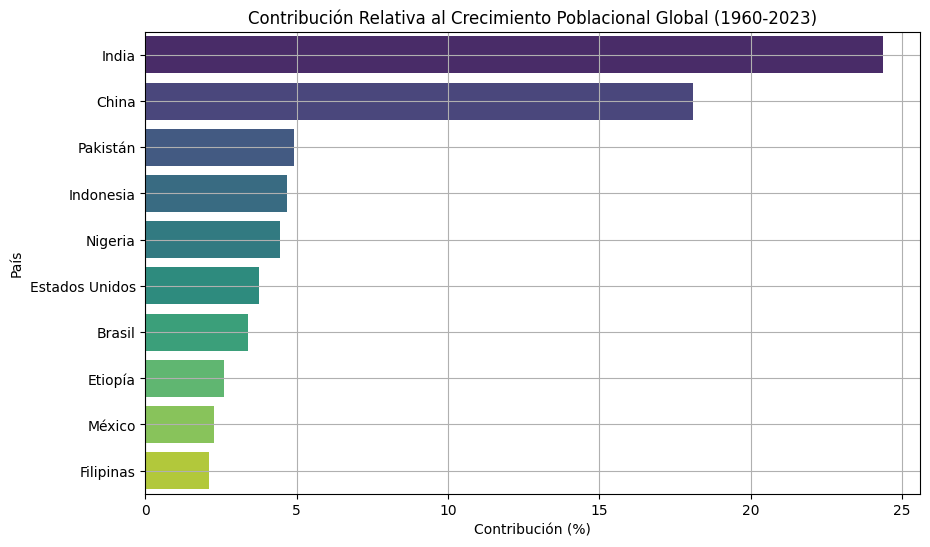

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración del gráfico
plt.figure(figsize=(10, 6))
sns.barplot(x='Contribution_Global', y='Country Name', data=top_contributors, palette='viridis')
plt.title('Contribución Relativa al Crecimiento Poblacional Global (1960-2023)')
plt.xlabel('Contribución (%)')
plt.ylabel('País')
plt.grid()
plt.show()


/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/usr/local/lib/python3.11/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Año 2024: 1,453,944,802
Año 2025: 1,469,819,701
Año 2026: 1,485,694,291
Año 2027: 1,501,568,574
Año 2028: 1,517,442,548


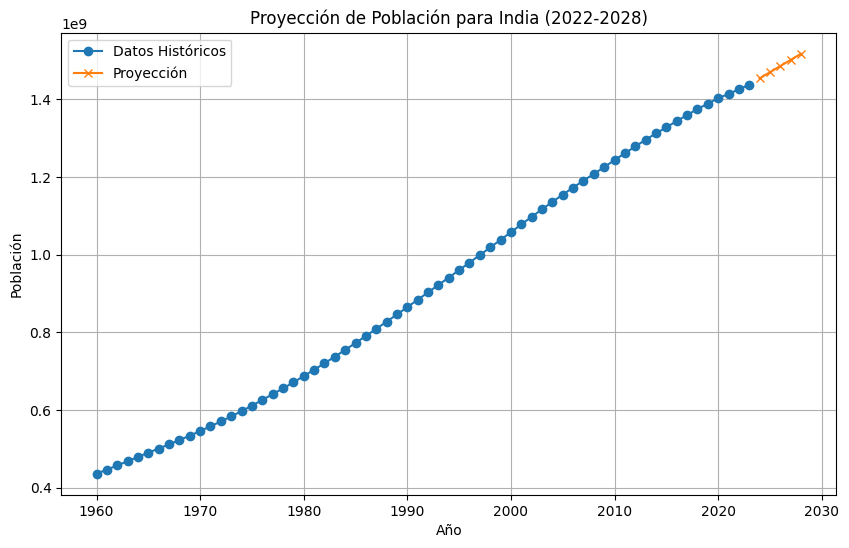


Proyección para Afganistán:
Año 2024: 42,017,980
Año 2025: 42,557,332
Año 2026: 43,073,826
Año 2027: 43,568,431
Año 2028: 44,042,076


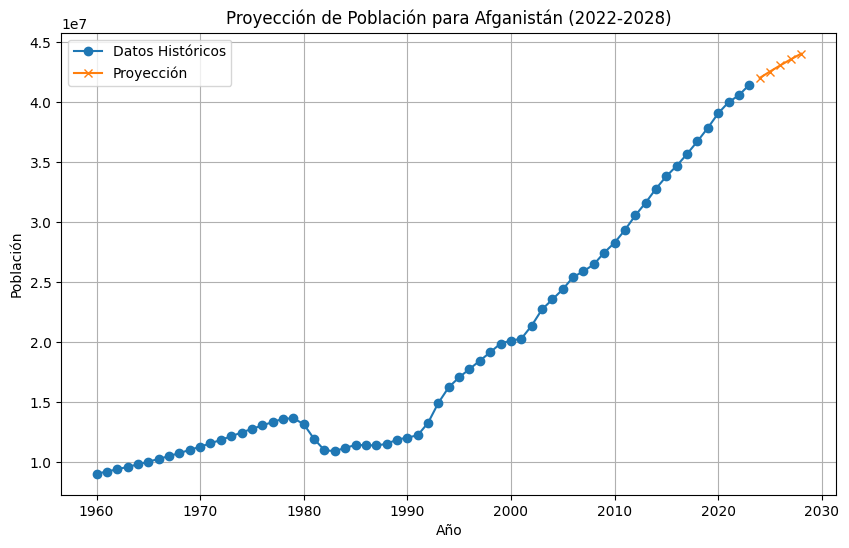


Proyección para Albania:
Año 2024: 2,740,608
Año 2025: 2,735,513
Año 2026: 2,730,673
Año 2027: 2,726,075
Año 2028: 2,721,708


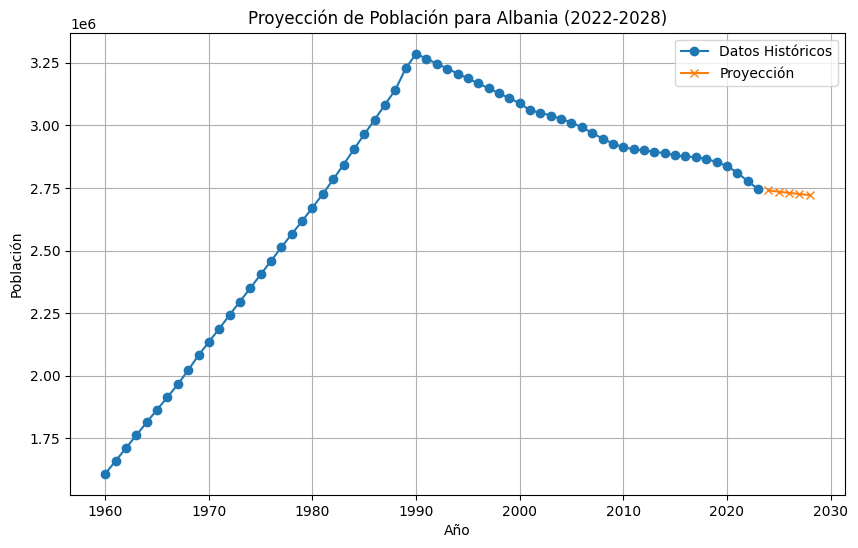


Proyección para Alemania:
Año 2024: 83,289,302
Año 2025: 83,297,596
Año 2026: 83,304,989
Año 2027: 83,311,580
Año 2028: 83,317,456


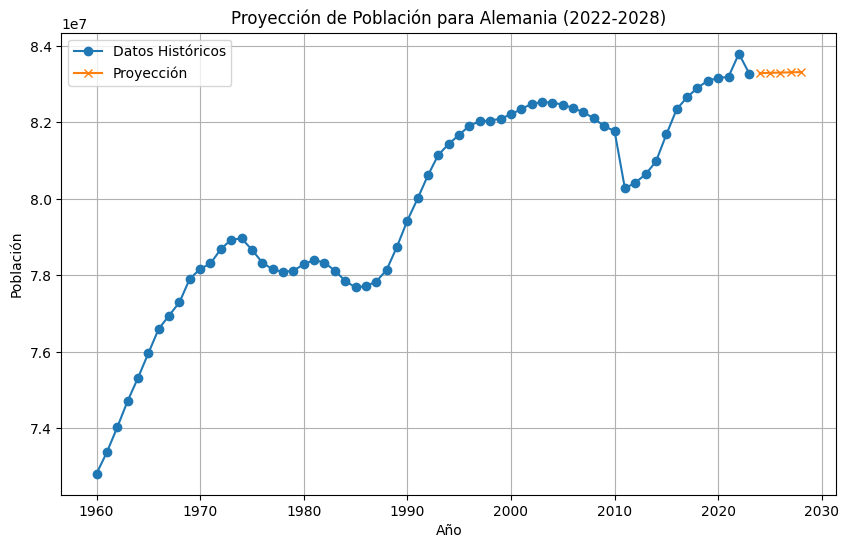


Proyección para Andorra:
Año 2024: 81,599
Año 2025: 81,985
Año 2026: 82,184
Año 2027: 82,287
Año 2028: 82,341


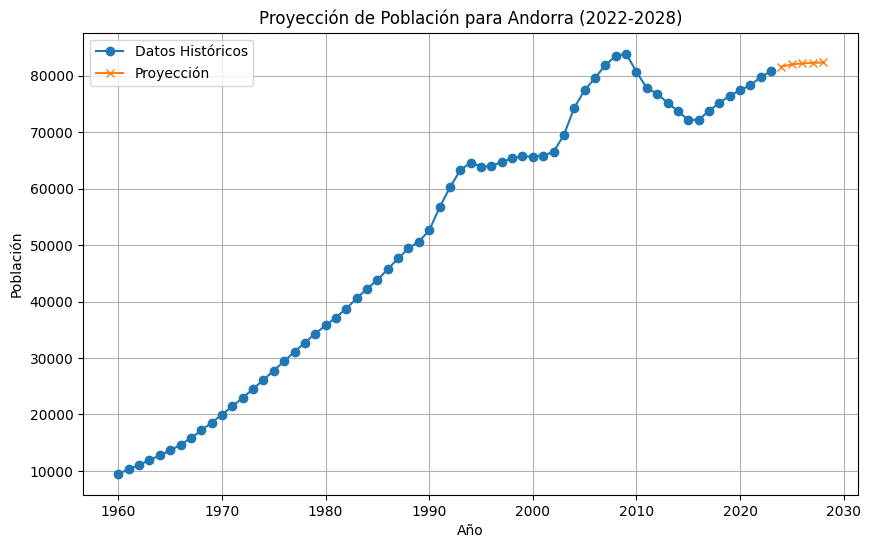


Proyección para Angola:


/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/usr/local/lib/python3.11/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Año 2024: 37,249,811
Año 2025: 37,749,715
Año 2026: 38,249,618
Año 2027: 38,749,520
Año 2028: 39,249,420


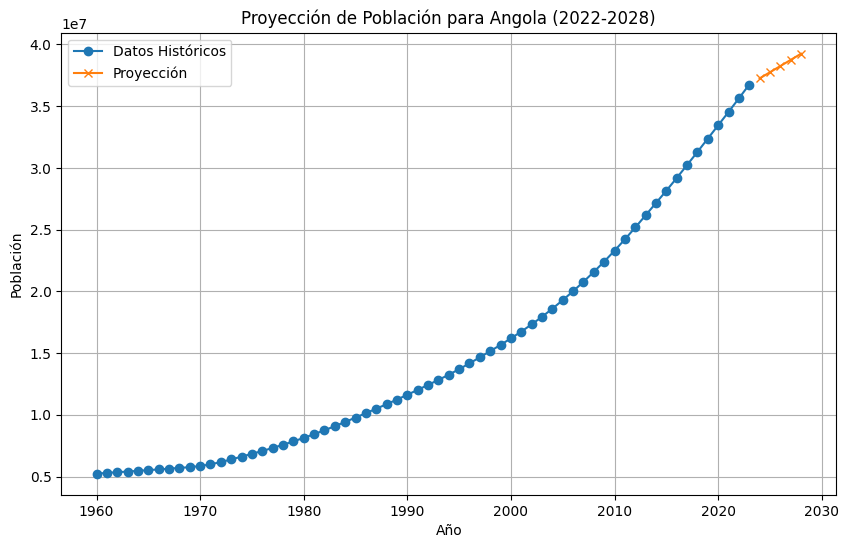

In [ ]:
# Configurar el rango de años
years = [str(year) for year in range(1960, 2024)]

# Seleccionar los datos de población para los países encontrados
data_for_model = data_paises_encontrados[['Country Name'] + years]

from statsmodels.tsa.arima.model import ARIMA
import matplotlib.pyplot as plt

def proyectar_poblacion(country_name, data, years, n_years=5):
    # Seleccionar datos del país
    country_data = data[data['Country Name'] == country_name]
    if country_data.empty:
        print(f"No se encontraron datos para el país: {country_name}")
        return None

    # Extraer datos de población como serie temporal
    population_series = country_data[years].values.flatten()

    # Crear el modelo ARIMA
    model = ARIMA(population_series, order=(1, 1, 1))
    model_fit = model.fit()

    # Proyectar población para los próximos n_years años
    forecast = model_fit.forecast(steps=n_years)
    forecast_years = [int(years[-1]) + i + 1 for i in range(n_years)]

    # Mostrar la proyección
    for year, pop in zip(forecast_years, forecast):
        print(f"Año {year}: {int(pop):,}")

    # Graficar resultados
    plt.figure(figsize=(10, 6))
    plt.plot(range(1960, 2024), population_series, label="Datos Históricos", marker='o')
    plt.plot(forecast_years, forecast, label="Proyección", marker='x')
    plt.title(f"Proyección de Población para {country_name} (2024-{forecast_years[-1]})")
    plt.xlabel("Año")
    plt.ylabel("Población")
    plt.legend()
    plt.grid()
    plt.show()

    return forecast

# Lista de años como columnas
years = [str(year) for year in range(1960, 2024)]

# Proyectar población para un país específico
proyeccion_india = proyectar_poblacion("India", data_for_model, years)

# Proyectar población para múltiples países
for country in paises_encontrados[:5]:  # Ejemplo: primeros 5 países
    print(f"\nProyección para {country}:")
    proyectar_poblacion(country, data_for_model, years)




Proyeccion por pais elegido


/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/usr/local/lib/python3.11/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Año 2024: 52,903,388
Año 2025: 53,485,613
Año 2026: 54,067,828
Año 2027: 54,650,032
Año 2028: 55,232,225


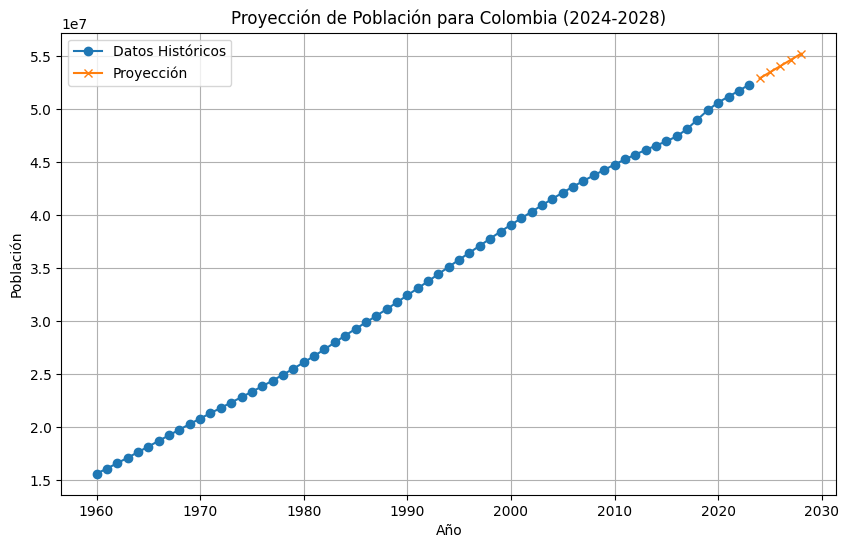


Proyección de población para Colombia (2022-2026):
Año 2022: 52,903,388
Año 2023: 53,485,613
Año 2024: 54,067,828
Año 2025: 54,650,032


In [ ]:
# Proyectar la población de Colombia para los próximos 5 años
proyeccion_colombia = proyectar_poblacion("Colombia", data_for_model, years)

# Mostrar los resultados
if proyeccion_colombia is not None:
    print("\nProyección de población para Colombia (2022-2026):")
    for i, year in enumerate(range(2022, 2026)):
        print(f"Año {year}: {int(proyeccion_colombia[i]):,}")


**Se proyectan los 5 paises con mayor y menor crecimiento**


Proyección de población para India:


/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/usr/local/lib/python3.11/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Año 2024: 1,453,944,802
Año 2025: 1,469,819,701
Año 2026: 1,485,694,291
Año 2027: 1,501,568,574
Año 2028: 1,517,442,548


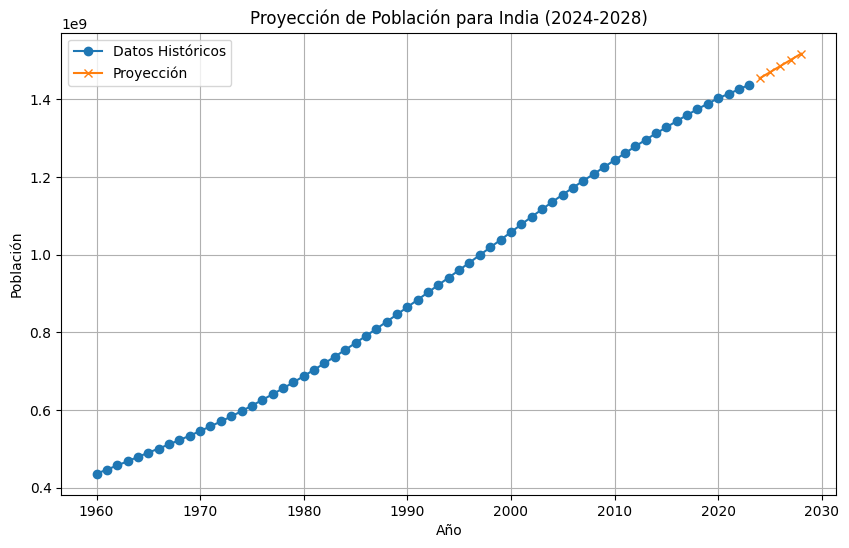


Proyección de población para China:
Año 2024: 1,417,361,363
Año 2025: 1,423,912,677
Año 2026: 1,430,365,445
Año 2027: 1,436,721,150
Año 2028: 1,442,981,252


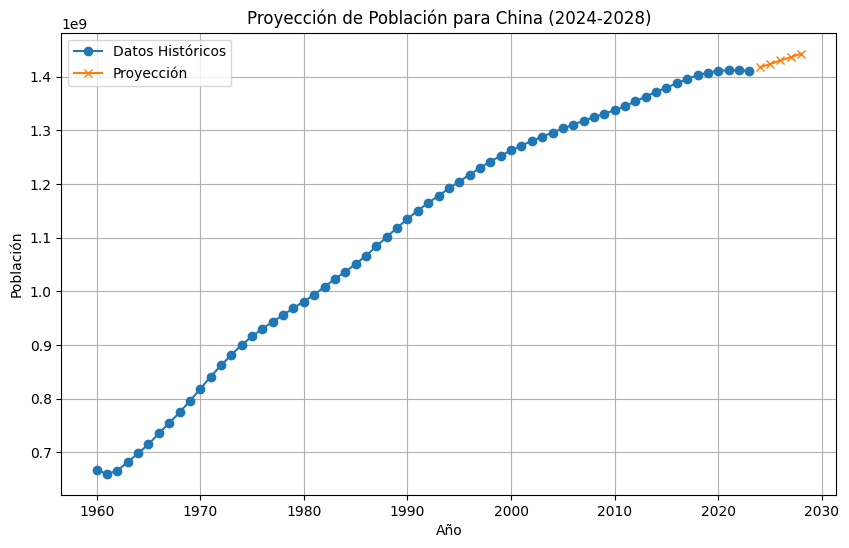


Proyección de población para Pakistán:


/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/usr/local/lib/python3.11/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Año 2024: 250,704,370
Año 2025: 253,904,221
Año 2026: 257,104,047
Año 2027: 260,303,848
Año 2028: 263,503,625


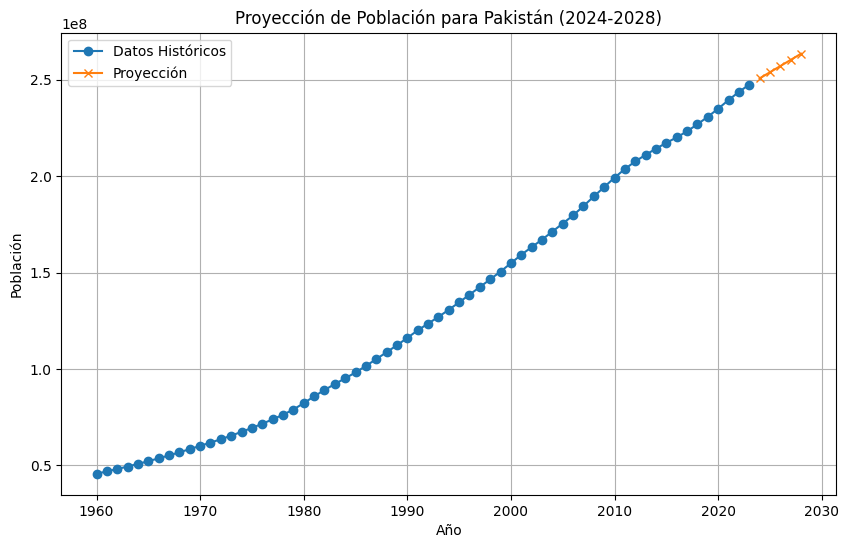


Proyección de población para Indonesia:
Año 2024: 284,078,303
Año 2025: 286,961,510
Año 2026: 289,839,695
Año 2027: 292,712,868
Año 2028: 295,581,037


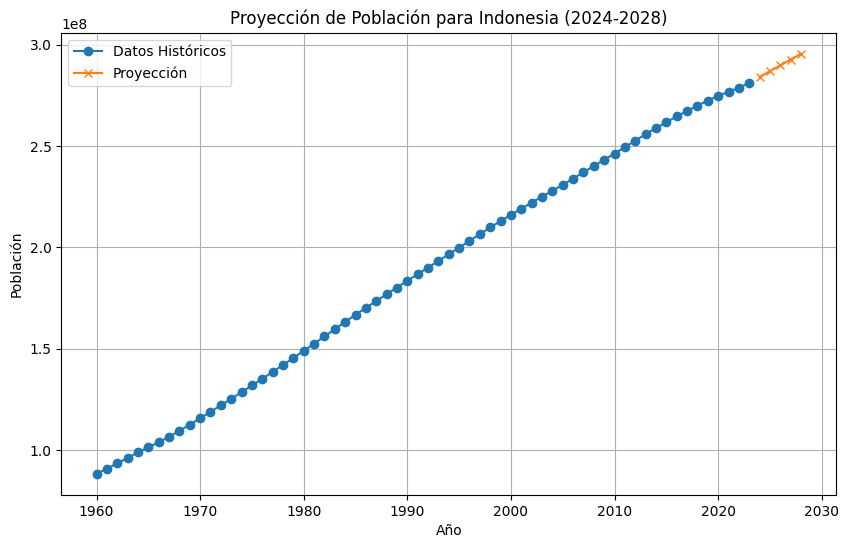


Proyección de población para Nigeria:


/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/usr/local/lib/python3.11/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Año 2024: 230,785,763
Año 2025: 233,688,567
Año 2026: 236,591,358
Año 2027: 239,494,134
Año 2028: 242,396,897


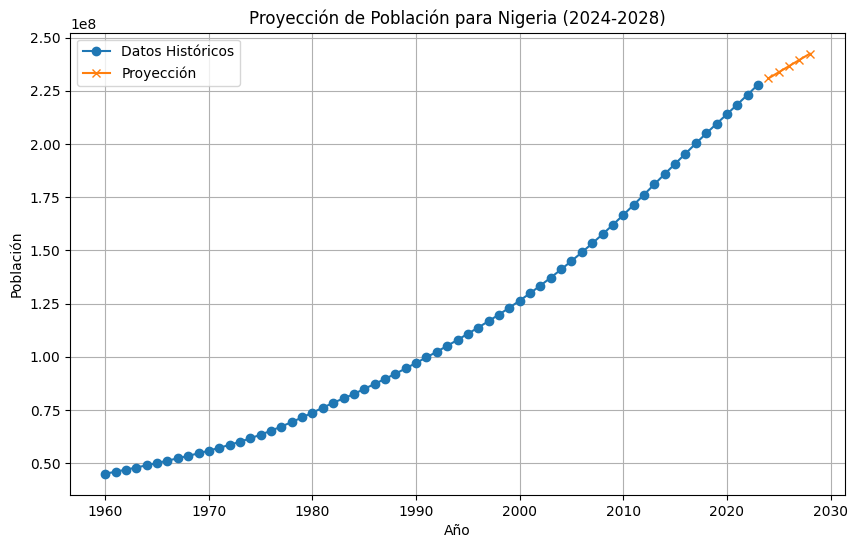


Proyección de población para Ucrania:
Año 2024: 37,595,519
Año 2025: 37,470,454
Año 2026: 37,356,548
Año 2027: 37,252,805
Año 2028: 37,158,318


/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'


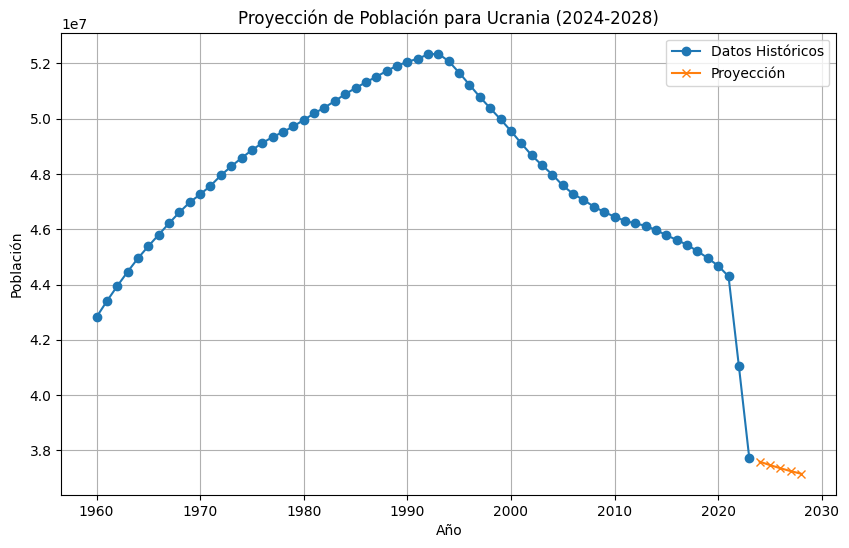


Proyección de población para Bulgaria:
Año 2024: 6,436,343
Año 2025: 6,427,162
Año 2026: 6,418,942
Año 2027: 6,411,582
Año 2028: 6,404,991


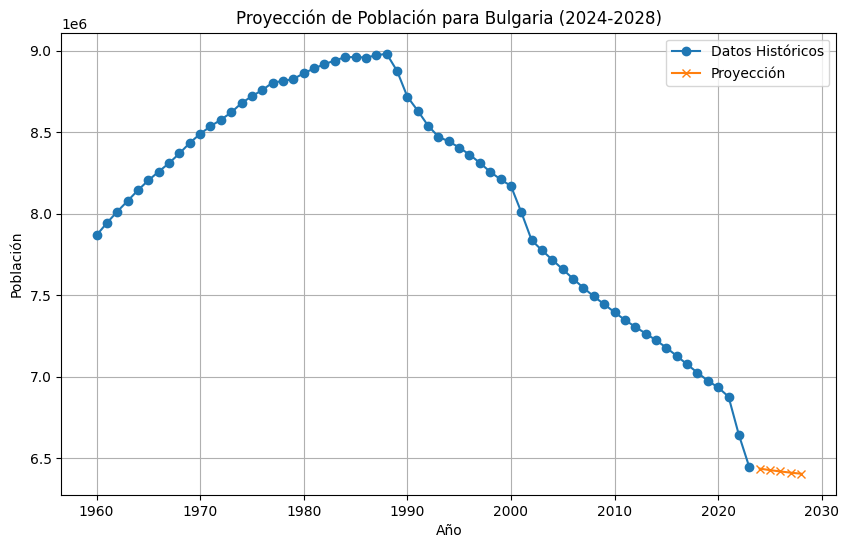


Proyección de población para Hungría:


/usr/local/lib/python3.11/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Año 2024: 9,590,583
Año 2025: 9,589,140
Año 2026: 9,587,839
Año 2027: 9,586,667
Año 2028: 9,585,611


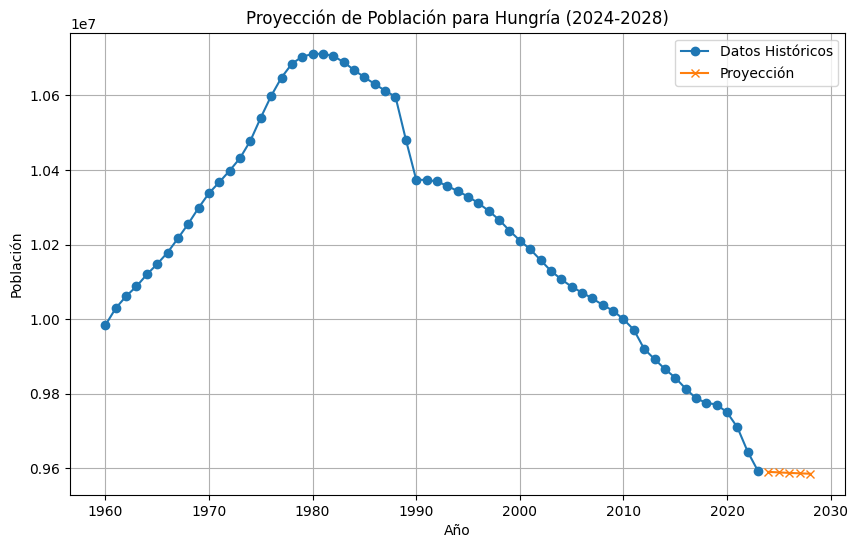


Proyección de población para Croacia:
Año 2024: 3,856,946
Año 2025: 3,854,452
Año 2026: 3,852,182
Año 2027: 3,850,116
Año 2028: 3,848,236


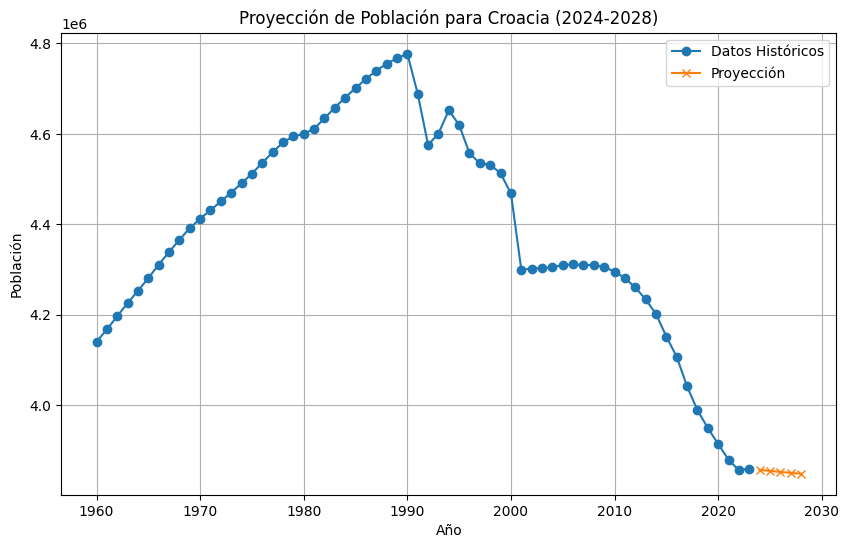


Proyección de población para Letonia:
Año 2024: 1,875,622

/usr/local/lib/python3.11/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "



Año 2025: 1,873,803
Año 2026: 1,871,989
Año 2027: 1,870,180
Año 2028: 1,868,375


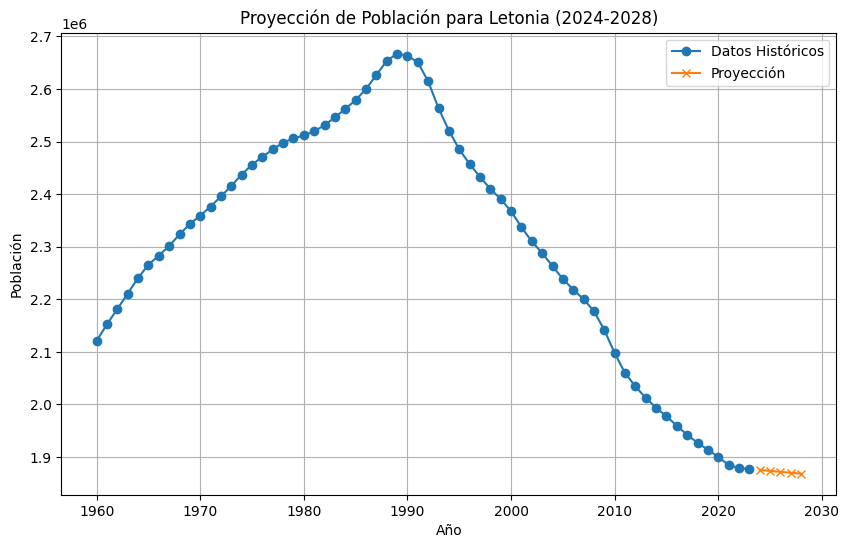




Mostrar las proyecciones para países con mayor crecimiento




Proyecciones para países con mayor crecimiento poblacional (2024-2028):
India: [1453944802, 1469819701, 1485694291, 1501568574, 1517442548]
China: [1417361363, 1423912677, 1430365445, 1436721150, 1442981252]
Pakistán: [250704370, 253904221, 257104047, 260303848, 263503625]
Indonesia: [284078303, 286961510, 289839695, 292712868, 295581037]
Nigeria: [230785763, 233688567, 236591358, 239494134, 242396897]

Proyecciones para países con menor crecimiento poblacional (2024-2028):
Ucrania: [37595519, 37470454, 37356548, 37252805, 37158318]
Bulgaria: [6436343, 6427162, 6418942, 6411582, 6404991]
Hungría: [9590583, 9589140, 9587839, 9586667, 9585611]
Croacia: [3856946, 3854452, 3852182, 3850116, 3848236]
Letonia: [1875622, 1873803, 1871989, 1870180, 1868375]


In [ ]:
# Listas de países con mayor y menor crecimiento
paises_mayor_crecimiento = ["India", "China", "Pakistán", "Indonesia", "Nigeria"]
paises_menor_crecimiento = ["Ucrania", "Bulgaria", "Hungría", "Croacia", "Letonia"]

# Proyectar población para múltiples países
def proyectar_poblacion_paises(lista_paises, data, years, n_years=5):
    proyecciones = {}
    for country in lista_paises:
        print(f"\nProyección de población para {country}:")
        forecast = proyectar_poblacion(country, data, years, n_years)
        if forecast is not None:
            proyecciones[country] = forecast
    return proyecciones

# Proyecciones para los países con mayor crecimiento poblacional
proyecciones_mayor_crecimiento = proyectar_poblacion_paises(
    paises_mayor_crecimiento, data_for_model, years
)

# Proyecciones para los países con menor crecimiento poblacional
proyecciones_menor_crecimiento = proyectar_poblacion_paises(
    paises_menor_crecimiento, data_for_model, years
)



**Interpretación General:

Estos países tienen las mayores tasas de crecimiento poblacional entre 1960 y 2023, y las proyecciones muestran que esta tendencia continuará:

India y China:

Son los dos países más poblados del mundo.
India sigue superando a China en términos de crecimiento absoluto, con un incremento de casi 33 millones de personas entre 2024 y 2028.
China también muestra un crecimiento significativo, pero a un ritmo ligeramente más lento debido a políticas demográficas (como el envejecimiento de la población y las tasas de fertilidad más bajas).

Pakistán, Indonesia y Nigeria:

Estos países están experimentando un rápido crecimiento debido a altas tasas de natalidad y mejoras en salud pública.

Nigeria destaca como el país africano con mayor contribución al crecimiento poblacional global, con un aumento de 11 millones de personas en este periodo.**

In [ ]:
# Mostrar las proyecciones para países con mayor crecimiento
print("\nProyecciones para países con mayor crecimiento poblacional (2024-2028):")
for country, forecast in proyecciones_mayor_crecimiento.items():
    print(f"{country}: {[int(value) for value in forecast]}")

# Mostrar las proyecciones para países con menor crecimiento
print("\nProyecciones para países con menor crecimiento poblacional (2024-2028):")
for country, forecast in proyecciones_menor_crecimiento.items():
    print(f"{country}: {[int(value) for value in forecast]}")



Proyecciones para países con mayor crecimiento poblacional (2024-2028):
India: [1453944802, 1469819701, 1485694291, 1501568574, 1517442548]
China: [1417361363, 1423912677, 1430365445, 1436721150, 1442981252]
Pakistán: [250704370, 253904221, 257104047, 260303848, 263503625]
Indonesia: [284078303, 286961510, 289839695, 292712868, 295581037]
Nigeria: [230785763, 233688567, 236591358, 239494134, 242396897]

Proyecciones para países con menor crecimiento poblacional (2024-2028):
Ucrania: [37595519, 37470454, 37356548, 37252805, 37158318]
Bulgaria: [6436343, 6427162, 6418942, 6411582, 6404991]
Hungría: [9590583, 9589140, 9587839, 9586667, 9585611]
Croacia: [3856946, 3854452, 3852182, 3850116, 3848236]
Letonia: [1875622, 1873803, 1871989, 1870180, 1868375]


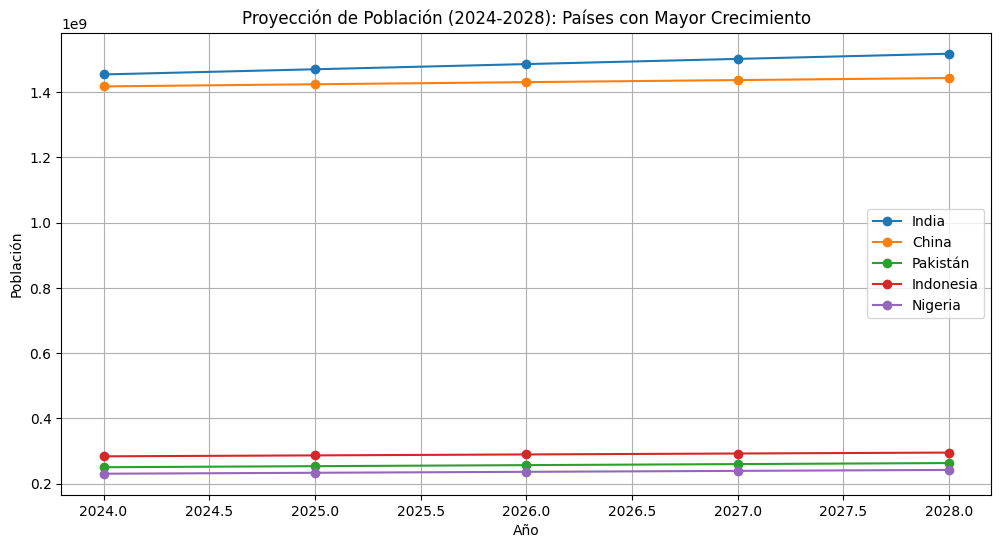

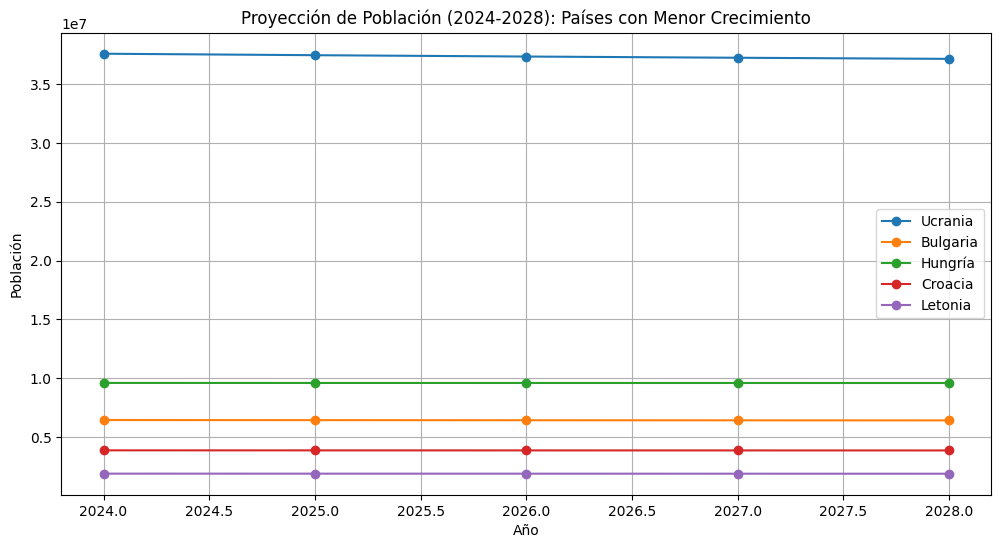

In [ ]:
# Graficar proyecciones de países con mayor crecimiento
plt.figure(figsize=(12, 6))
for country, forecast in proyecciones_mayor_crecimiento.items():
    plt.plot(range(2024, 2029), forecast, marker='o', label=country)
plt.title("Proyección de Población (2024-2028): Países con Mayor Crecimiento")
plt.xlabel("Año")
plt.ylabel("Población")
plt.legend()
plt.grid()
plt.show()

# Graficar proyecciones de países con menor crecimiento
plt.figure(figsize=(12, 6))
for country, forecast in proyecciones_menor_crecimiento.items():
    plt.plot(range(2024, 2029), forecast, marker='o', label=country)
plt.title("Proyección de Población (2024-2028): Países con Menor Crecimiento")
plt.xlabel("Año")
plt.ylabel("Población")
plt.legend()
plt.grid()
plt.show()


**Evaluacion del modelo**

In [ ]:
# Datos reales del país para el rango 2010-2023
country_name = "India"  # Cambia al país que deseas analizar
years_real = [str(year) for year in range(2010, 2024)]  # Años del rango
country_data = data_cleaned[data_cleaned['Country Name'] == country_name]

# Extraer la serie temporal real
population_real = country_data[years_real].values.flatten()

from statsmodels.tsa.arima.model import ARIMA

# Extraer datos históricos hasta 2009
years_train = [str(year) for year in range(1960, 2010)]  # Entrenamiento hasta 2009
population_train = country_data[years_train].values.flatten()

# Ajustar el modelo ARIMA con datos hasta 2009
model = ARIMA(population_train, order=(1, 1, 1))  # Ajusta los parámetros según tu caso
model_fit = model.fit()

# Proyectar población desde 2010 hasta 2023
population_pred = model_fit.forecast(steps=len(years_real))


/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/usr/local/lib/python3.11/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
